# Data augment and knowledge distillation

In [8]:
import os
import torch
import torch.optim as optim
import numpy as np
import xgboost as xgb
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

# Import your original code
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))
from src.dataloader import CustomBikeDataset
from src.instashap import InstaSHAP, ShapleySampler, surrogate
from src.distill_utils import DistillationTrainer, TeacherWrapper

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [9]:
# load data
dataset = CustomBikeDataset(root_dir="../data", dataset_name="bike_sharing", seed=37)

X_train, y_train, X_val, y_val = dataset.pull_trnval_data()
X_test, y_test = dataset.tstX, dataset.tstY

print(f"Training Data: {X_train.shape}")

# Standardize features
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8

X_train_scaled = (X_train - mean) / std
X_val_scaled = (X_val - mean) / std
X_test_scaled = (X_test - mean) / std

Processing file: ../data/bike_sharing/hour.csv
Splitting Train/Val with seed: 37
Training Data: (9732, 13)


In [10]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# %% [3] Step 1: Train the Teacher (Black-box)
# We use XGBoost as the Teacher, as it typically performs best on tabular data.
print("Training Teacher (XGBoost)...")
teacher_model = xgb.XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=6, 
    n_jobs=-1
)
teacher_model.fit(X_train_scaled, y_train)

# Evaluate Teacher
y_pred_teacher = teacher_model.predict(X_test_scaled)
mse_teacher = mean_squared_error(y_test, y_pred_teacher)
print(f"Teacher MSE: {mse_teacher:.4f} (This is the upper bound we aim to approach)")

Training Teacher (XGBoost)...
Teacher MSE: 0.1308 (This is the upper bound we aim to approach)


Splitting Train/Val with seed: 0
trnX trnY (9732, 13) (9732, 1)
Epoch 0
MSE for train and val: 1.9846059706585886, 1.9880486524369707
--- 0.263 seconds in epoch ---
Epoch 1
MSE for train and val: 2.191482229238572, 2.1047180375591097
--- 0.211 seconds in epoch ---
Epoch 2
MSE for train and val: 1.0613932989636745, 1.052325242600816
--- 0.202 seconds in epoch ---
Epoch 3
MSE for train and val: 0.8143476875438809, 0.7942581613796935
--- 0.194 seconds in epoch ---
Epoch 4
MSE for train and val: 1.4042138682071976, 1.3653164379431193
--- 0.196 seconds in epoch ---
Epoch 5
MSE for train and val: 0.5931315077792713, 0.5802024912156497
--- 0.197 seconds in epoch ---
Epoch 6
MSE for train and val: 1.1310061765238293, 1.1358560398074888
--- 0.245 seconds in epoch ---
Epoch 7
MSE for train and val: 0.46460685593644513, 0.4603152467934315
--- 0.187 seconds in epoch ---
Epoch 8
MSE for train and val: 0.4312449175757823, 0.4338157700857262
--- 0.191 seconds in epoch ---
Epoch 9
MSE for train and va

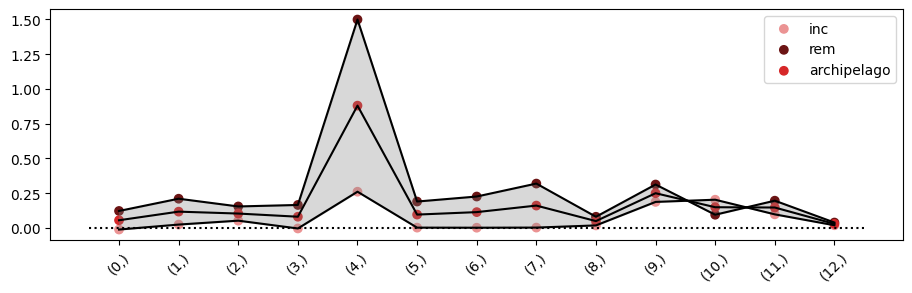

new_selections [(4,)]
selections [(4,)]
new_cands []
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (9,), (10,), (11,), (12,)]
0.11981797218322754 seconds
nr 1
archipelago_tensor (12, 2, 4171)
semitruth torch.Size([4171, 1])


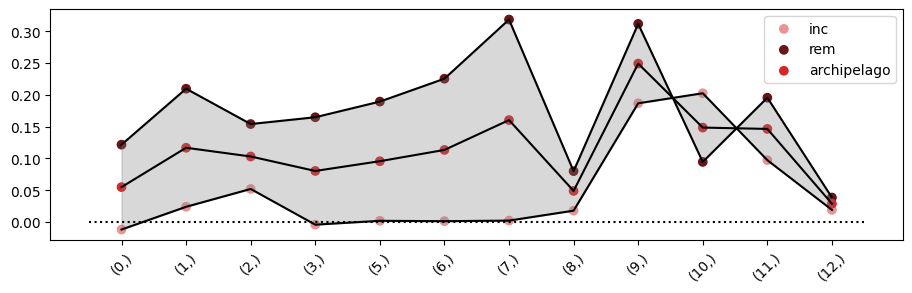

new_selections [(9,)]
selections [(4,), (9,)]
new_cands [(4, 9)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (10,), (11,), (12,), (4, 9)]
0.2133471965789795 seconds
nr 2
archipelago_tensor (12, 2, 4171)
semitruth torch.Size([4171, 1])


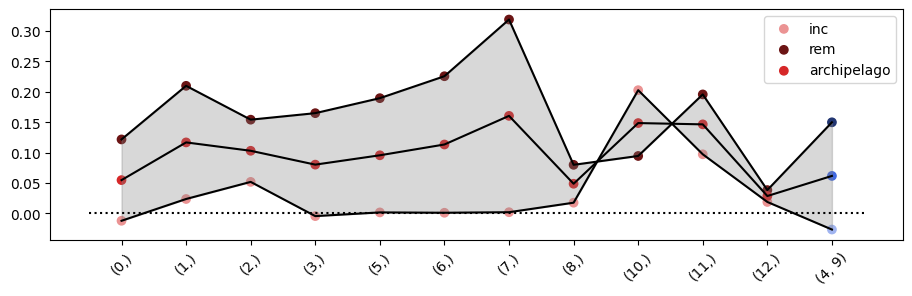

new_selections [(7,)]
selections [(4,), (9,), (7,)]
new_cands [(4, 9), (4, 7), (7, 9)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (8,), (10,), (11,), (12,), (4, 9), (4, 7), (7, 9)]
0.3121941089630127 seconds
nr 3
archipelago_tensor (13, 2, 4171)
semitruth torch.Size([4171, 1])


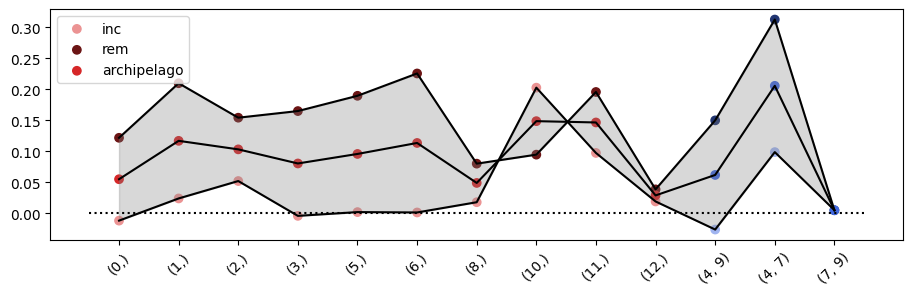

new_selections [(4, 7)]
selections [(4,), (9,), (7,), (4, 7)]
new_cands [(4, 9), (4, 7), (7, 9)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (8,), (10,), (11,), (12,), (4, 9), (7, 9)]
0.43478989601135254 seconds
nr 4
archipelago_tensor (12, 2, 4171)
semitruth torch.Size([4171, 1])


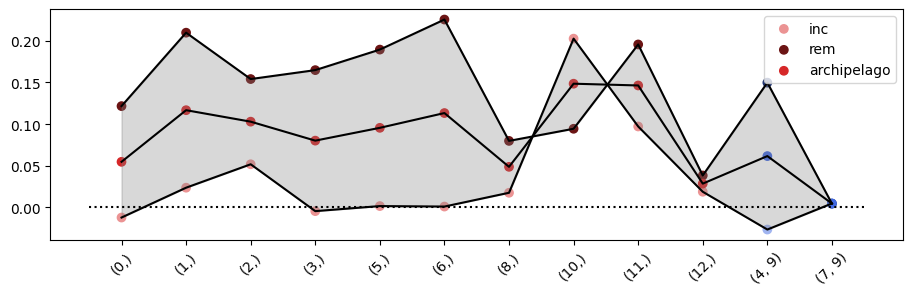

new_selections [(10,)]
selections [(4,), (9,), (7,), (4, 7), (10,)]
new_cands [(4, 9), (4, 7), (4, 10), (7, 9), (9, 10), (7, 10)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (8,), (11,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10)]
0.7058730125427246 seconds
nr 5
archipelago_tensor (14, 2, 4171)
semitruth torch.Size([4171, 1])


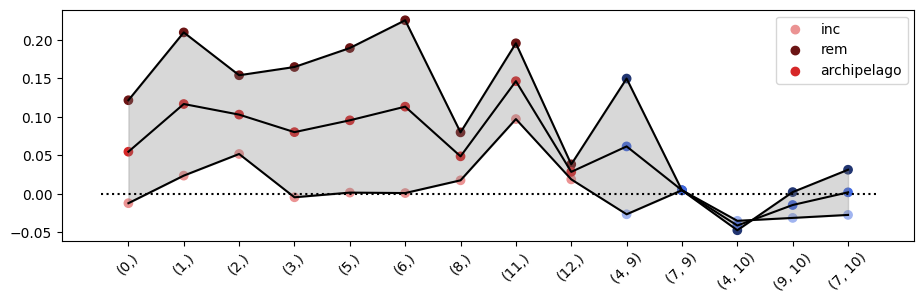

new_selections [(11,)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (7, 9), (9, 10), (9, 11), (7, 10), (7, 11), (10, 11)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (8,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10), (4, 11), (9, 11), (7, 11), (10, 11)]
0.8302359580993652 seconds
nr 6
archipelago_tensor (17, 2, 4171)
semitruth torch.Size([4171, 1])


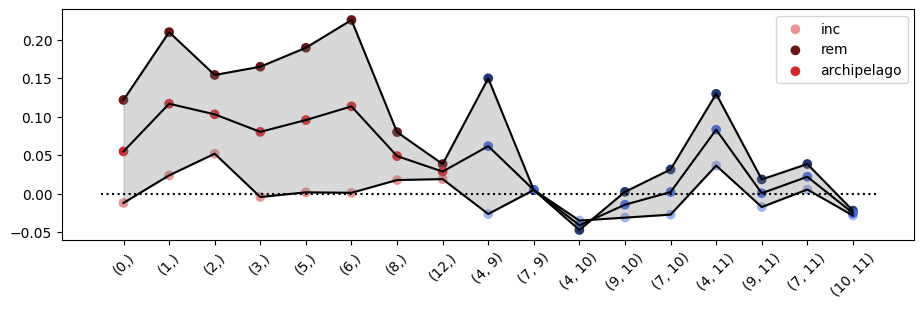

new_selections [(1,)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (7, 9), (9, 10), (9, 11), (1, 9), (7, 10), (7, 11), (1, 7), (10, 11), (1, 10), (1, 11)]
candidates [(0,), (2,), (3,), (5,), (6,), (8,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10), (4, 11), (9, 11), (7, 11), (10, 11), (1, 4), (1, 9), (1, 7), (1, 10), (1, 11)]
0.9734001159667969 seconds
nr 7
archipelago_tensor (21, 2, 4171)
semitruth torch.Size([4171, 1])


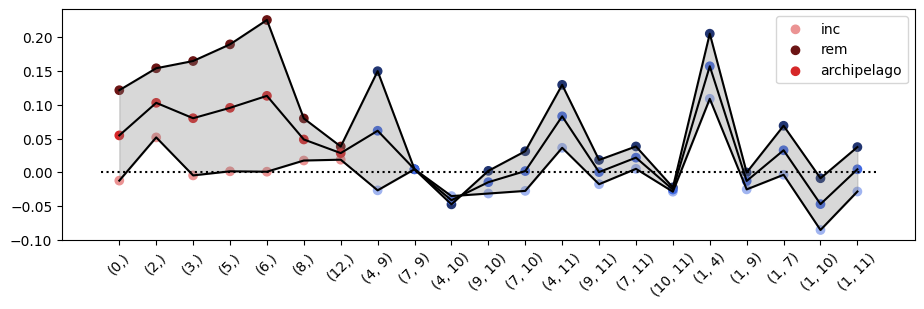

new_selections [(1, 4)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (7, 9), (9, 10), (9, 11), (1, 9), (7, 10), (7, 11), (1, 7), (10, 11), (1, 10), (1, 11)]
candidates [(0,), (2,), (3,), (5,), (6,), (8,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10), (4, 11), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11)]
1.1534740924835205 seconds
nr 8
archipelago_tensor (20, 2, 4171)
semitruth torch.Size([4171, 1])


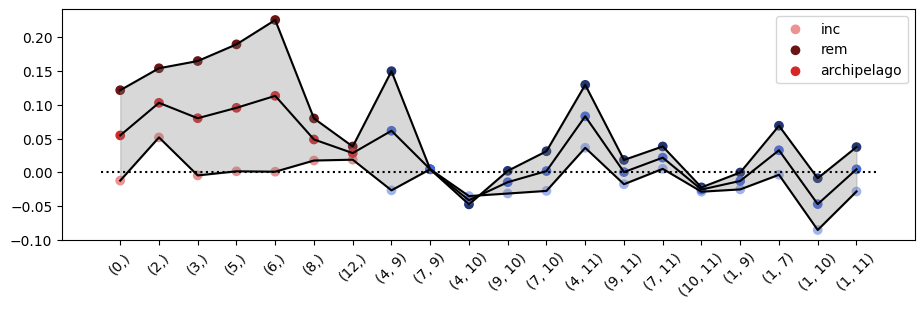

new_selections [(6,)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4), (6,)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (4, 6), (7, 9), (9, 10), (9, 11), (1, 9), (6, 9), (7, 10), (7, 11), (1, 7), (6, 7), (10, 11), (1, 10), (6, 10), (1, 11), (6, 11), (1, 6)]
candidates [(0,), (2,), (3,), (5,), (8,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10), (4, 11), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11), (4, 6), (6, 9), (6, 7), (6, 10), (6, 11), (1, 6)]
1.3213980197906494 seconds
nr 9
archipelago_tensor (25, 2, 4171)
semitruth torch.Size([4171, 1])


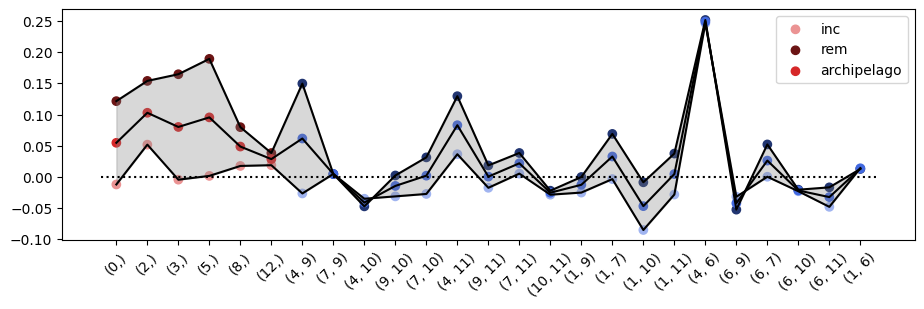

new_selections [(4, 6)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4), (6,), (4, 6)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (4, 6), (7, 9), (9, 10), (9, 11), (1, 9), (6, 9), (7, 10), (7, 11), (1, 7), (6, 7), (10, 11), (1, 10), (6, 10), (1, 11), (6, 11), (1, 6)]
candidates [(0,), (2,), (3,), (5,), (8,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10), (4, 11), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11), (6, 9), (6, 7), (6, 10), (6, 11), (1, 6)]
1.5243589878082275 seconds
nr 10
archipelago_tensor (24, 2, 4171)
semitruth torch.Size([4171, 1])


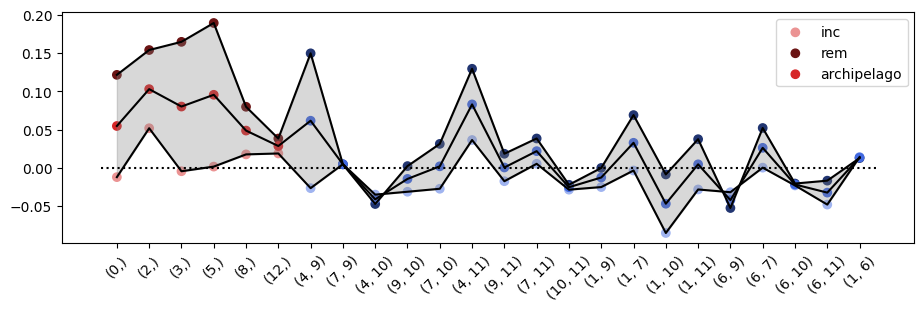

new_selections [(2,)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4), (6,), (4, 6), (2,)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (4, 6), (2, 4), (7, 9), (9, 10), (9, 11), (1, 9), (6, 9), (2, 9), (7, 10), (7, 11), (1, 7), (6, 7), (2, 7), (10, 11), (1, 10), (6, 10), (2, 10), (1, 11), (6, 11), (2, 11), (1, 6), (1, 2), (2, 6)]
candidates [(0,), (3,), (5,), (8,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10), (4, 11), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11), (6, 9), (6, 7), (6, 10), (6, 11), (1, 6), (2, 4), (2, 9), (2, 7), (2, 10), (2, 11), (1, 2), (2, 6)]
1.7216839790344238 seconds
nr 11
archipelago_tensor (30, 2, 4171)
semitruth torch.Size([4171, 1])


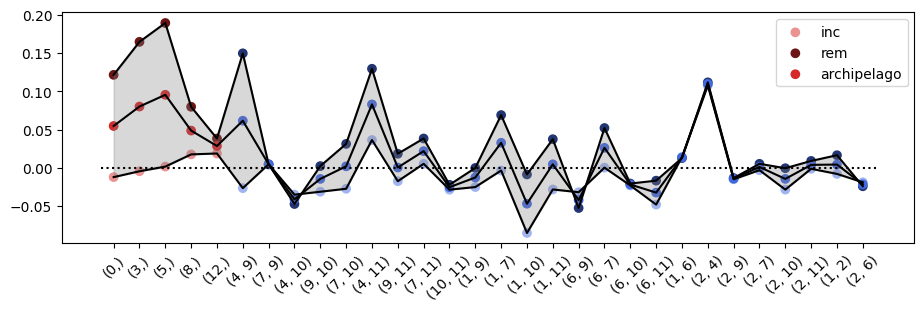

new_selections [(2, 4)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4), (6,), (4, 6), (2,), (2, 4)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (4, 6), (2, 4), (7, 9), (9, 10), (9, 11), (1, 9), (6, 9), (2, 9), (7, 10), (7, 11), (1, 7), (6, 7), (2, 7), (10, 11), (1, 10), (6, 10), (2, 10), (1, 11), (6, 11), (2, 11), (1, 6), (1, 2), (2, 6)]
candidates [(0,), (3,), (5,), (8,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10), (4, 11), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11), (6, 9), (6, 7), (6, 10), (6, 11), (1, 6), (2, 9), (2, 7), (2, 10), (2, 11), (1, 2), (2, 6)]
1.9485809803009033 seconds
nr 12
archipelago_tensor (29, 2, 4171)
semitruth torch.Size([4171, 1])


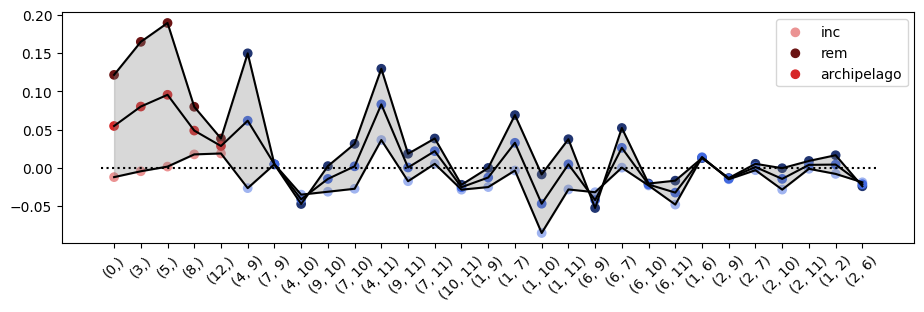

new_selections [(5,)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4), (6,), (4, 6), (2,), (2, 4), (5,)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (4, 6), (2, 4), (4, 5), (7, 9), (9, 10), (9, 11), (1, 9), (6, 9), (2, 9), (5, 9), (7, 10), (7, 11), (1, 7), (6, 7), (2, 7), (5, 7), (10, 11), (1, 10), (6, 10), (2, 10), (5, 10), (1, 11), (6, 11), (2, 11), (5, 11), (1, 6), (1, 2), (1, 5), (2, 6), (5, 6), (2, 5)]
candidates [(0,), (3,), (8,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10), (4, 11), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11), (6, 9), (6, 7), (6, 10), (6, 11), (1, 6), (2, 9), (2, 7), (2, 10), (2, 11), (1, 2), (2, 6), (4, 5), (5, 9), (5, 7), (5, 10), (5, 11), (1, 5), (5, 6), (2, 5)]
2.168060064315796 seconds
nr 13
archipelago_tensor (36, 2, 4171)
semitruth torch.Size([4171, 1])


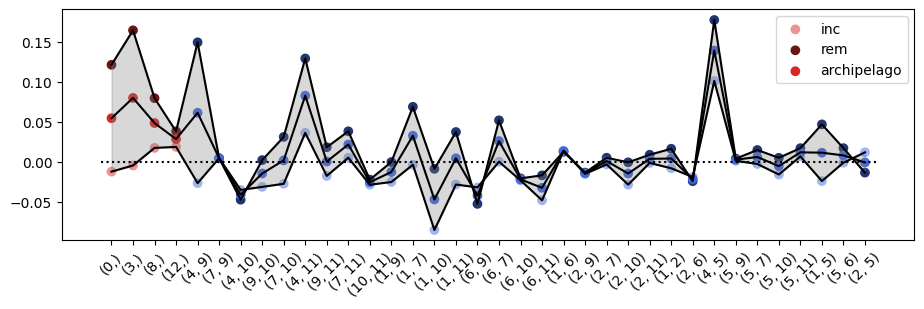

new_selections [(4, 5)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4), (6,), (4, 6), (2,), (2, 4), (5,), (4, 5)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (4, 6), (2, 4), (4, 5), (7, 9), (9, 10), (9, 11), (1, 9), (6, 9), (2, 9), (5, 9), (7, 10), (7, 11), (1, 7), (6, 7), (2, 7), (5, 7), (10, 11), (1, 10), (6, 10), (2, 10), (5, 10), (1, 11), (6, 11), (2, 11), (5, 11), (1, 6), (1, 2), (1, 5), (2, 6), (5, 6), (2, 5)]
candidates [(0,), (3,), (8,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10), (4, 11), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11), (6, 9), (6, 7), (6, 10), (6, 11), (1, 6), (2, 9), (2, 7), (2, 10), (2, 11), (1, 2), (2, 6), (5, 9), (5, 7), (5, 10), (5, 11), (1, 5), (5, 6), (2, 5)]
2.454409122467041 seconds
nr 14
archipelago_tensor (35, 2, 4171)
semitruth torch.Size([4171, 1])


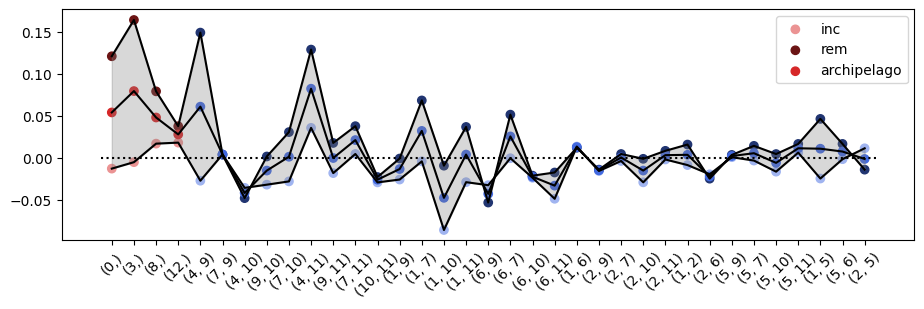

new_selections [(4, 11)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4), (6,), (4, 6), (2,), (2, 4), (5,), (4, 5), (4, 11)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (4, 6), (2, 4), (4, 5), (7, 9), (9, 10), (9, 11), (1, 9), (6, 9), (2, 9), (5, 9), (7, 10), (7, 11), (1, 7), (6, 7), (2, 7), (5, 7), (10, 11), (1, 10), (6, 10), (2, 10), (5, 10), (1, 11), (6, 11), (2, 11), (5, 11), (1, 6), (1, 2), (1, 5), (2, 6), (5, 6), (2, 5)]
candidates [(0,), (3,), (8,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11), (6, 9), (6, 7), (6, 10), (6, 11), (1, 6), (2, 9), (2, 7), (2, 10), (2, 11), (1, 2), (2, 6), (5, 9), (5, 7), (5, 10), (5, 11), (1, 5), (5, 6), (2, 5)]
2.7190840244293213 seconds
nr 15
archipelago_tensor (34, 2, 4171)
semitruth torch.Size([4171, 1])


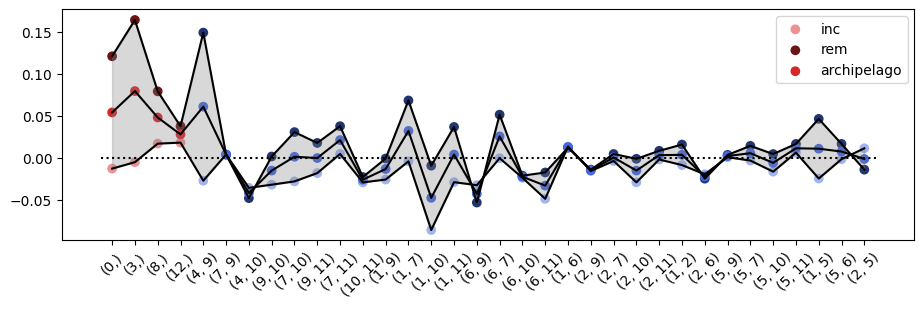

new_selections [(3,)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4), (6,), (4, 6), (2,), (2, 4), (5,), (4, 5), (4, 11), (3,)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (4, 6), (2, 4), (4, 5), (3, 4), (7, 9), (9, 10), (9, 11), (1, 9), (6, 9), (2, 9), (5, 9), (3, 9), (7, 10), (7, 11), (1, 7), (6, 7), (2, 7), (5, 7), (3, 7), (10, 11), (1, 10), (6, 10), (2, 10), (5, 10), (3, 10), (1, 11), (6, 11), (2, 11), (5, 11), (3, 11), (1, 6), (1, 2), (1, 5), (1, 3), (2, 6), (5, 6), (3, 6), (2, 5), (2, 3), (3, 5)]
candidates [(0,), (8,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11), (6, 9), (6, 7), (6, 10), (6, 11), (1, 6), (2, 9), (2, 7), (2, 10), (2, 11), (1, 2), (2, 6), (5, 9), (5, 7), (5, 10), (5, 11), (1, 5), (5, 6), (2, 5), (3, 4), (3, 9), (3, 7), (3, 10), (3, 11), (1, 3), (3, 6), (2, 3), (3, 5)]
2.9712610244750977 seconds
nr 16
archipelago_tensor (42, 2, 4171)
semitruth torch.Size([4171, 1])


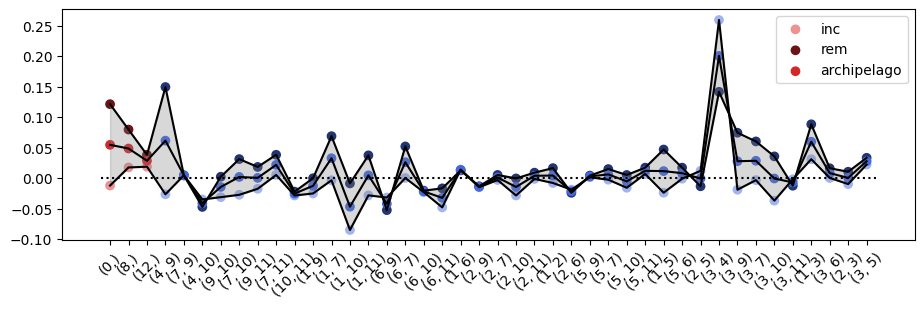

new_selections [(3, 4)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4), (6,), (4, 6), (2,), (2, 4), (5,), (4, 5), (4, 11), (3,), (3, 4)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (4, 6), (2, 4), (4, 5), (3, 4), (7, 9), (9, 10), (9, 11), (1, 9), (6, 9), (2, 9), (5, 9), (3, 9), (7, 10), (7, 11), (1, 7), (6, 7), (2, 7), (5, 7), (3, 7), (10, 11), (1, 10), (6, 10), (2, 10), (5, 10), (3, 10), (1, 11), (6, 11), (2, 11), (5, 11), (3, 11), (1, 6), (1, 2), (1, 5), (1, 3), (2, 6), (5, 6), (3, 6), (2, 5), (2, 3), (3, 5)]
candidates [(0,), (8,), (12,), (4, 9), (7, 9), (4, 10), (9, 10), (7, 10), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11), (6, 9), (6, 7), (6, 10), (6, 11), (1, 6), (2, 9), (2, 7), (2, 10), (2, 11), (1, 2), (2, 6), (5, 9), (5, 7), (5, 10), (5, 11), (1, 5), (5, 6), (2, 5), (3, 9), (3, 7), (3, 10), (3, 11), (1, 3), (3, 6), (2, 3), (3, 5)]
3.2889459133148193 seconds
nr 17
archipelago_tensor (41, 2, 4171)
semitruth torch.Size([4171, 1])


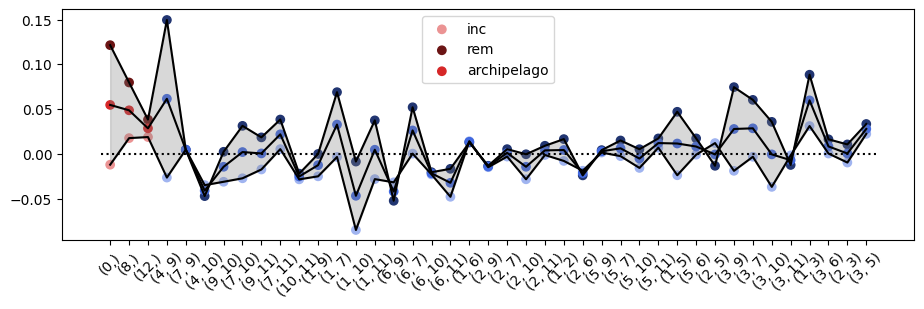

new_selections [(4, 9)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4), (6,), (4, 6), (2,), (2, 4), (5,), (4, 5), (4, 11), (3,), (3, 4), (4, 9)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (4, 6), (2, 4), (4, 5), (3, 4), (7, 9), (9, 10), (9, 11), (1, 9), (6, 9), (2, 9), (5, 9), (3, 9), (7, 10), (7, 11), (1, 7), (6, 7), (2, 7), (5, 7), (3, 7), (10, 11), (1, 10), (6, 10), (2, 10), (5, 10), (3, 10), (1, 11), (6, 11), (2, 11), (5, 11), (3, 11), (1, 6), (1, 2), (1, 5), (1, 3), (2, 6), (5, 6), (3, 6), (2, 5), (2, 3), (3, 5)]
candidates [(0,), (8,), (12,), (7, 9), (4, 10), (9, 10), (7, 10), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11), (6, 9), (6, 7), (6, 10), (6, 11), (1, 6), (2, 9), (2, 7), (2, 10), (2, 11), (1, 2), (2, 6), (5, 9), (5, 7), (5, 10), (5, 11), (1, 5), (5, 6), (2, 5), (3, 9), (3, 7), (3, 10), (3, 11), (1, 3), (3, 6), (2, 3), (3, 5)]
3.5891289710998535 seconds
nr 18
archipelago_tensor (40, 2, 4171)
semitruth torch.Size([4171, 1])


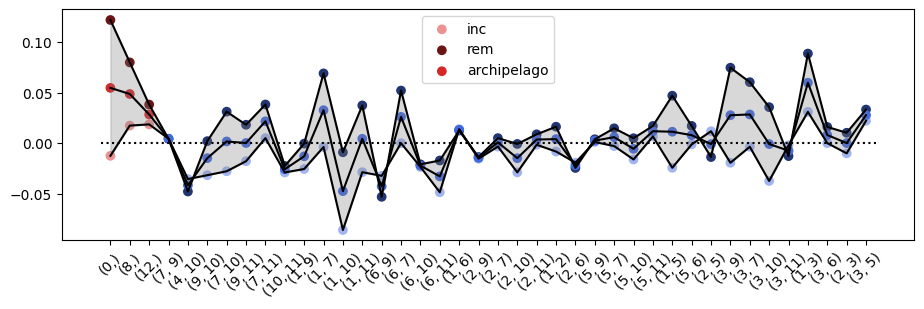

new_selections [(1, 3)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4), (6,), (4, 6), (2,), (2, 4), (5,), (4, 5), (4, 11), (3,), (3, 4), (4, 9), (1, 3)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (4, 6), (2, 4), (4, 5), (3, 4), (7, 9), (9, 10), (9, 11), (1, 9), (6, 9), (2, 9), (5, 9), (3, 9), (7, 10), (7, 11), (1, 7), (6, 7), (2, 7), (5, 7), (3, 7), (10, 11), (1, 10), (6, 10), (2, 10), (5, 10), (3, 10), (1, 11), (6, 11), (2, 11), (5, 11), (3, 11), (1, 6), (1, 2), (1, 5), (1, 3), (2, 6), (5, 6), (3, 6), (2, 5), (2, 3), (3, 5)]
candidates [(0,), (8,), (12,), (7, 9), (4, 10), (9, 10), (7, 10), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11), (6, 9), (6, 7), (6, 10), (6, 11), (1, 6), (2, 9), (2, 7), (2, 10), (2, 11), (1, 2), (2, 6), (5, 9), (5, 7), (5, 10), (5, 11), (1, 5), (5, 6), (2, 5), (3, 9), (3, 7), (3, 10), (3, 11), (3, 6), (2, 3), (3, 5)]
3.8806769847869873 seconds
nr 19
archipelago_tensor (39, 2, 4171)
semitruth torch.Size([4171, 1])


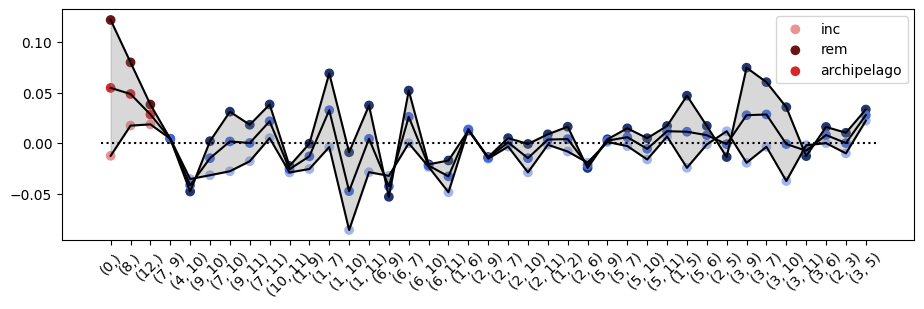

new_selections [(0,)]
selections [(4,), (9,), (7,), (4, 7), (10,), (11,), (1,), (1, 4), (6,), (4, 6), (2,), (2, 4), (5,), (4, 5), (4, 11), (3,), (3, 4), (4, 9), (1, 3), (0,)]
new_cands [(4, 9), (4, 7), (4, 10), (4, 11), (1, 4), (4, 6), (2, 4), (4, 5), (3, 4), (0, 4), (7, 9), (9, 10), (9, 11), (1, 9), (6, 9), (2, 9), (5, 9), (3, 9), (0, 9), (7, 10), (7, 11), (1, 7), (6, 7), (2, 7), (5, 7), (3, 7), (0, 7), (10, 11), (1, 10), (6, 10), (2, 10), (5, 10), (3, 10), (0, 10), (1, 11), (6, 11), (2, 11), (5, 11), (3, 11), (0, 11), (1, 6), (1, 2), (1, 5), (1, 3), (0, 1), (2, 6), (5, 6), (3, 6), (0, 6), (2, 5), (2, 3), (0, 2), (3, 5), (0, 5), (0, 3)]
candidates [(8,), (12,), (7, 9), (4, 10), (9, 10), (7, 10), (9, 11), (7, 11), (10, 11), (1, 9), (1, 7), (1, 10), (1, 11), (6, 9), (6, 7), (6, 10), (6, 11), (1, 6), (2, 9), (2, 7), (2, 10), (2, 11), (1, 2), (2, 6), (5, 9), (5, 7), (5, 10), (5, 11), (1, 5), (5, 6), (2, 5), (3, 9), (3, 7), (3, 10), (3, 11), (3, 6), (2, 3), (3, 5), (0, 4), (0, 9), (0, 7), 

In [11]:
results_path = "../results/"
exp_folder = results_path+'_'+ "demo" +'_simple_testing/'
os.makedirs(exp_folder, exist_ok=True)

from sian.models import TrainingArgs
mlp_args = TrainingArgs(batch_size=32, number_of_epochs=10, learning_rate=5e-3, device=device) 
mlp_args.model_config.net_name = "MLP"
mlp_args.model_config.sizes = [-1, 128, 256, 128, -1]
mlp_args.model_config.is_masked = True  
mlp_args.saving_settings.exp_folder = exp_folder
 
my_surrogate = surrogate(mlp_args=mlp_args, dataset_obj=dataset, max_number_of_rounds=20)
interactions = my_surrogate.get_interactions(device=device)
transform_matrix = my_surrogate.get_transform_matrix()

print(f"\nFound interactions: {interactions}")

In [12]:
num_features = X_train.shape[1]
# interactions = [(4,), (10,), (9,), (1,), (1, 4), (11,), (4, 11), (7,), (4, 7), (6,), (4, 6), (4, 9), (0,), (0, 4), (8,), (2,), (2, 4), (5,), (0, 6), (0, 5)]
student_model = InstaSHAP(interactions=interactions, transform_matrix=transform_matrix).to(device) 

optimizer = optim.Adam(student_model.parameters(), lr=1e-3)
sampler = ShapleySampler(num_features=num_features)

# %% [5] Step 3: Distillation Training
# Initialize the DistillationTrainer
# augment_factor=1 means generating 1 augmented sample for every real sample (2x data size)
distiller = DistillationTrainer(
    student_model=student_model,
    teacher_model=teacher_model,
    optimizer=optimizer,
    sampler=sampler,
    device=device
)

# Start training
# We use more epochs here because we have more data and smoother labels (less overfitting risk)
loss_history = distiller.train(train_loader, num_epochs=50, augment_factor=1)

# %% [6] Evaluate Student
student_model.eval()
with torch.no_grad():
    # Note: During testing, S is all ones (full set) to predict y
    S_full = torch.ones_like(X_test_tensor).to(device)
    y_pred_student = student_model(X_test_tensor.to(device), S_full).cpu().numpy()

mse_student = mean_squared_error(y_test, y_pred_student)
print(f"Student (InstaSHAP) MSE: {mse_student:.4f}")
print(f"Improvement over Teacher: {mse_student - mse_teacher:.4f} (Lower is better, ideal is 0)")

Start Distillation Training for 50 epochs...


Epoch 1/50, Distillation Loss: 17.773588


Epoch 2/50, Distillation Loss: 10.586072


Epoch 3/50, Distillation Loss: 9.232024


Epoch 4/50, Distillation Loss: 8.629287


...

Epoch 46/50, Distillation Loss: 6.105133


Epoch 47/50, Distillation Loss: 6.201456


Epoch 48/50, Distillation Loss: 6.087164


Epoch 49/50, Distillation Loss: 6.021652


Epoch 50/50, Distillation Loss: 6.142213
Student (InstaSHAP) MSE: 0.7797
Improvement over Teacher: 0.6489 (Lower is better, ideal is 0)


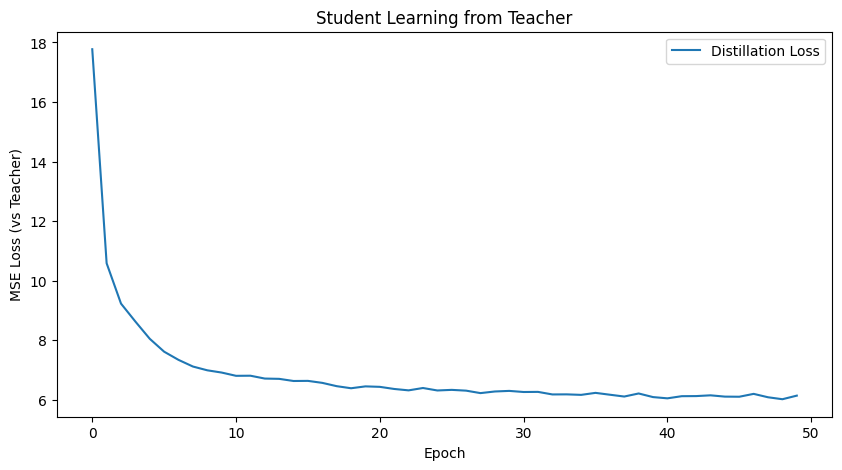

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Distillation Loss')
plt.title('Student Learning from Teacher')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (vs Teacher)')
plt.legend()
plt.show()

Start Baseline Training (Direct on Y) for 50 epochs...
Epoch 10/50, Baseline Loss: 7.085236
Epoch 20/50, Baseline Loss: 6.496798
Epoch 30/50, Baseline Loss: 6.311890
Epoch 40/50, Baseline Loss: 6.399041
Epoch 50/50, Baseline Loss: 6.257329


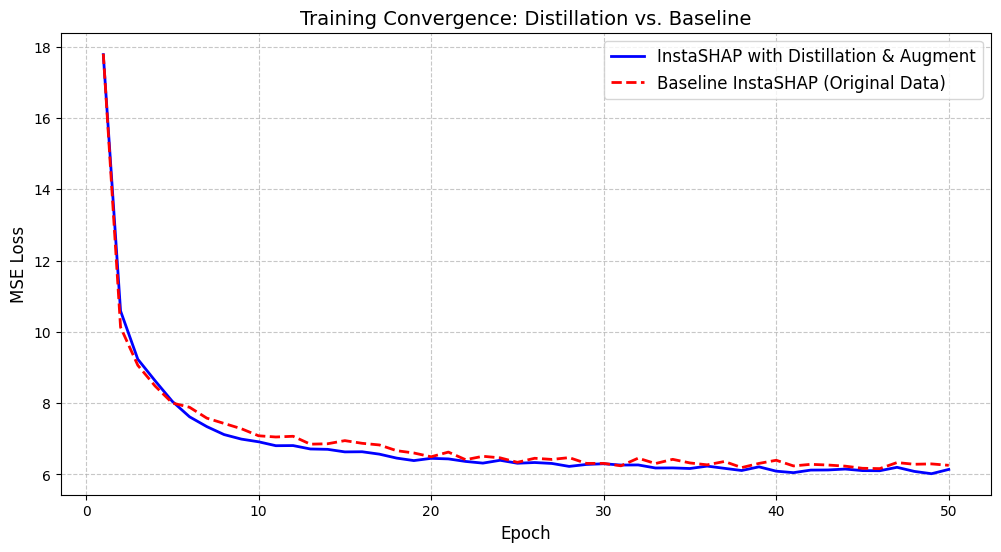


Final Test MSE (Distillation): 0.779708
Final Test MSE (Baseline):      0.884345
Improvement: 11.83%


In [14]:
# %% [7] Compare with Baseline InstaSHAP (Direct training on labels)
import copy

# 1. 初始化 Baseline 模型（结构与 Student 相同）
baseline_model = InstaSHAP(interactions=interactions, transform_matrix=transform_matrix).to(device)
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

# 2. 训练 Baseline 模型并记录 Loss
baseline_loss_history = []
num_epochs = 50  # 与蒸馏训练保持一致的 epoch 数
print(f"Start Baseline Training (Direct on Y) for {num_epochs} epochs...")

baseline_model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    total_samples = 0
    
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        # 采样 Shapley 掩码 S
        S_batch = sampler.sample(batch_size=x_batch.shape[0], paired_sampling=True).to(device)
        
        baseline_optimizer.zero_grad()
        # 直接拟合原始标签 Y
        outputs = baseline_model(x_batch, S_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        baseline_optimizer.step()
        
        epoch_loss += loss.item() * x_batch.size(0)
        total_samples += x_batch.size(0)
    
    avg_loss = epoch_loss / total_samples
    baseline_loss_history.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Baseline Loss: {avg_loss:.6f}")

# 3. 绘制对比图
plt.figure(figsize=(12, 6))
plt.plot(range(1, num_epochs + 1), loss_history, label='InstaSHAP with Distillation & Augment', color='blue', linewidth=2)
plt.plot(range(1, num_epochs + 1), baseline_loss_history, label='Baseline InstaSHAP (Original Data)', color='red', linestyle='--', linewidth=2)

plt.title('Training Convergence: Distillation vs. Baseline', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# 保存图片（可选）
plt.savefig('loss_comparison.png')
plt.show()

# 4. 测试集最终效果对比
baseline_model.eval()
with torch.no_grad():
    S_full = torch.ones_like(X_test_tensor).to(device)
    y_pred_baseline = baseline_model(X_test_tensor.to(device), S_full).cpu().numpy()

mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print("\n" + "="*30)
print(f"Final Test MSE (Distillation): {mse_student:.6f}")
print(f"Final Test MSE (Baseline):      {mse_baseline:.6f}")
print(f"Improvement: {((mse_baseline - mse_student) / mse_baseline * 100):.2f}%")
print("="*30)

正在重新运行实验以收集详细的 Epoch 数据...
Training Distillation Model...


Training Baseline Model...


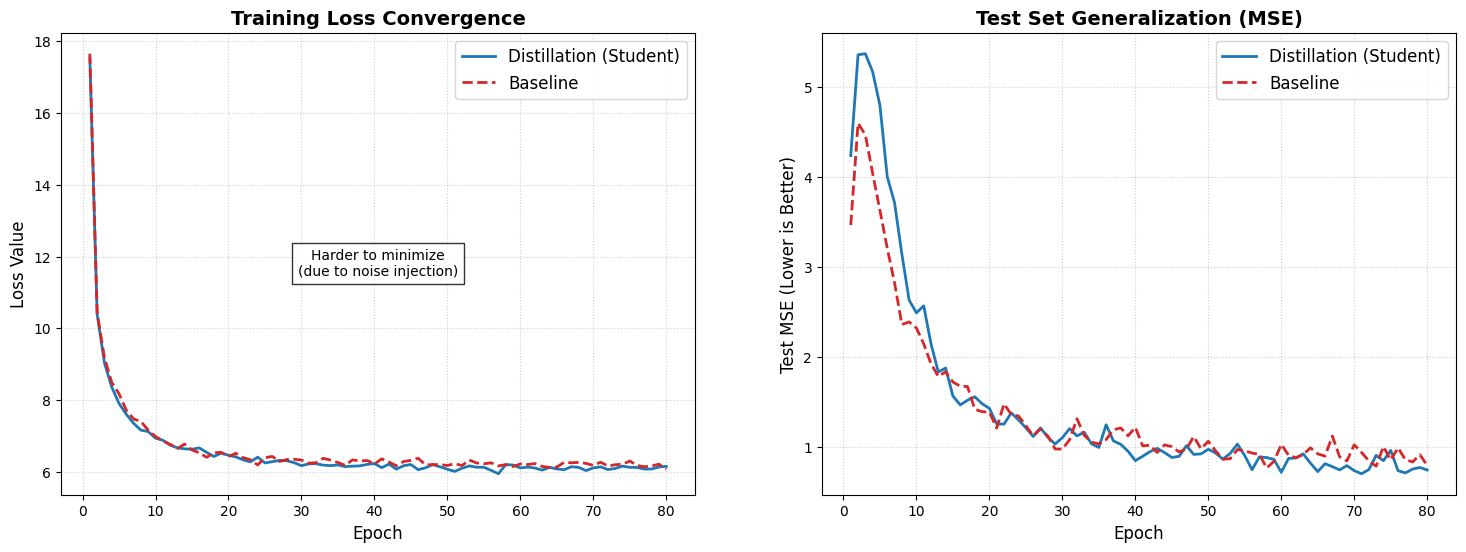

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import copy
import torch
import torch.optim as optim

# ==========================================
# 1. 准备工作：重新初始化模型以获取完整的曲线数据
# ==========================================
# 注意：这里假设你之前的 notebook 环境中 interactions, transform_matrix, teacher_model 等变量依然存在

print("正在重新运行实验以收集详细的 Epoch 数据...")

# --- 设置参数 ---
num_epochs_viz = 80  # 你可以根据需要修改这个数值
history = {
    'distill_train': [], 'distill_test': [],
    'baseline_train': [], 'baseline_test': []
}

# --- 重新初始化 Student (Distillation) 模型 ---
student_viz = InstaSHAP(interactions=interactions, transform_matrix=transform_matrix).to(device)
opt_student = optim.Adam(student_viz.parameters(), lr=1e-3)
# 重新实例化 Distiller (确保从头开始训练)
distiller_viz = DistillationTrainer(student_viz, teacher_model, opt_student, sampler, device)

# --- 重新初始化 Baseline 模型 ---
baseline_viz = InstaSHAP(interactions=interactions, transform_matrix=transform_matrix).to(device)
opt_baseline = optim.Adam(baseline_viz.parameters(), lr=1e-3)
criterion_viz = torch.nn.MSELoss()

# 准备测试集数据 (全 1 mask)
S_full = torch.ones_like(X_test_tensor).to(device)

# ==========================================
# 2. 运行训练循环并记录数据
# ==========================================

# --- A. 训练 Distillation 模型 ---
print("Training Distillation Model...")
for epoch in range(num_epochs_viz):
    # 1. 训练一轮 (使用 distiller 的 train_epoch 方法)
    train_loss = distiller_viz.train_epoch(train_loader, augment_factor=1)
    
    # 2. 测试一轮
    student_viz.eval()
    with torch.no_grad():
        y_pred = student_viz(X_test_tensor.to(device), S_full).cpu().numpy()
    test_loss = mean_squared_error(y_test, y_pred)
    student_viz.train() # 切回训练模式
    
    history['distill_train'].append(train_loss)
    history['distill_test'].append(test_loss)

# --- B. 训练 Baseline 模型 ---
print("Training Baseline Model...")
baseline_viz.train()
for epoch in range(num_epochs_viz):
    # 1. 训练一轮
    epoch_loss = 0.0
    total_samples = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        S_batch = sampler.sample(batch_size=x_batch.shape[0], paired_sampling=True).to(device)
        
        opt_baseline.zero_grad()
        outputs = baseline_viz(x_batch, S_batch)
        loss = criterion_viz(outputs, y_batch)
        loss.backward()
        opt_baseline.step()
        
        epoch_loss += loss.item() * x_batch.size(0)
        total_samples += x_batch.size(0)
    train_loss = epoch_loss / total_samples
    
    # 2. 测试一轮
    baseline_viz.eval()
    with torch.no_grad():
        y_pred = baseline_viz(X_test_tensor.to(device), S_full).cpu().numpy()
    test_loss = mean_squared_error(y_test, y_pred)
    baseline_viz.train()
    
    history['baseline_train'].append(train_loss)
    history['baseline_test'].append(test_loss)

# ==========================================
# 3. 生成两张对比图
# ==========================================
epochs = range(1, num_epochs_viz + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- 图 1: Training Loss ---
# 展示为什么训练集结果看起来“一般”
ax1.plot(epochs, history['distill_train'], label='Distillation (Student)', color='#1f77b4', linewidth=2)
ax1.plot(epochs, history['baseline_train'], label='Baseline', color='#d62728', linestyle='--', linewidth=2)
ax1.set_title('Training Loss Convergence', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss Value', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=12)
ax1.text(0.5, 0.5, 'Harder to minimize\n(due to noise injection)', transform=ax1.transAxes, 
         ha='center', va='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

# --- 图 2: Test Loss (Generalization) ---
# 展示真正的提升在哪里
ax2.plot(epochs, history['distill_test'], label='Distillation (Student)', color='#1f77b4', linewidth=2)
ax2.plot(epochs, history['baseline_test'], label='Baseline', color='#d62728', linestyle='--', linewidth=2)
ax2.set_title('Test Set Generalization (MSE)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Test MSE (Lower is Better)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=12)

# # 标注 Gap
# final_gap = history['baseline_test'][-1] - history['distill_test'][-1]
# ax2.annotate(f'Better Generalization\nGap: {final_gap:.3f}', 
#              xy=(num_epochs_viz, history['distill_test'][-1]), 
#              xytext=(num_epochs_viz-10, history['distill_test'][-1]+0.2),
#              arrowprops=dict(facecolor='black', shrink=0.05))

# plt.tight_layout()
# plt.savefig('train_vs_test_trends.png', dpi=300)
# plt.show()

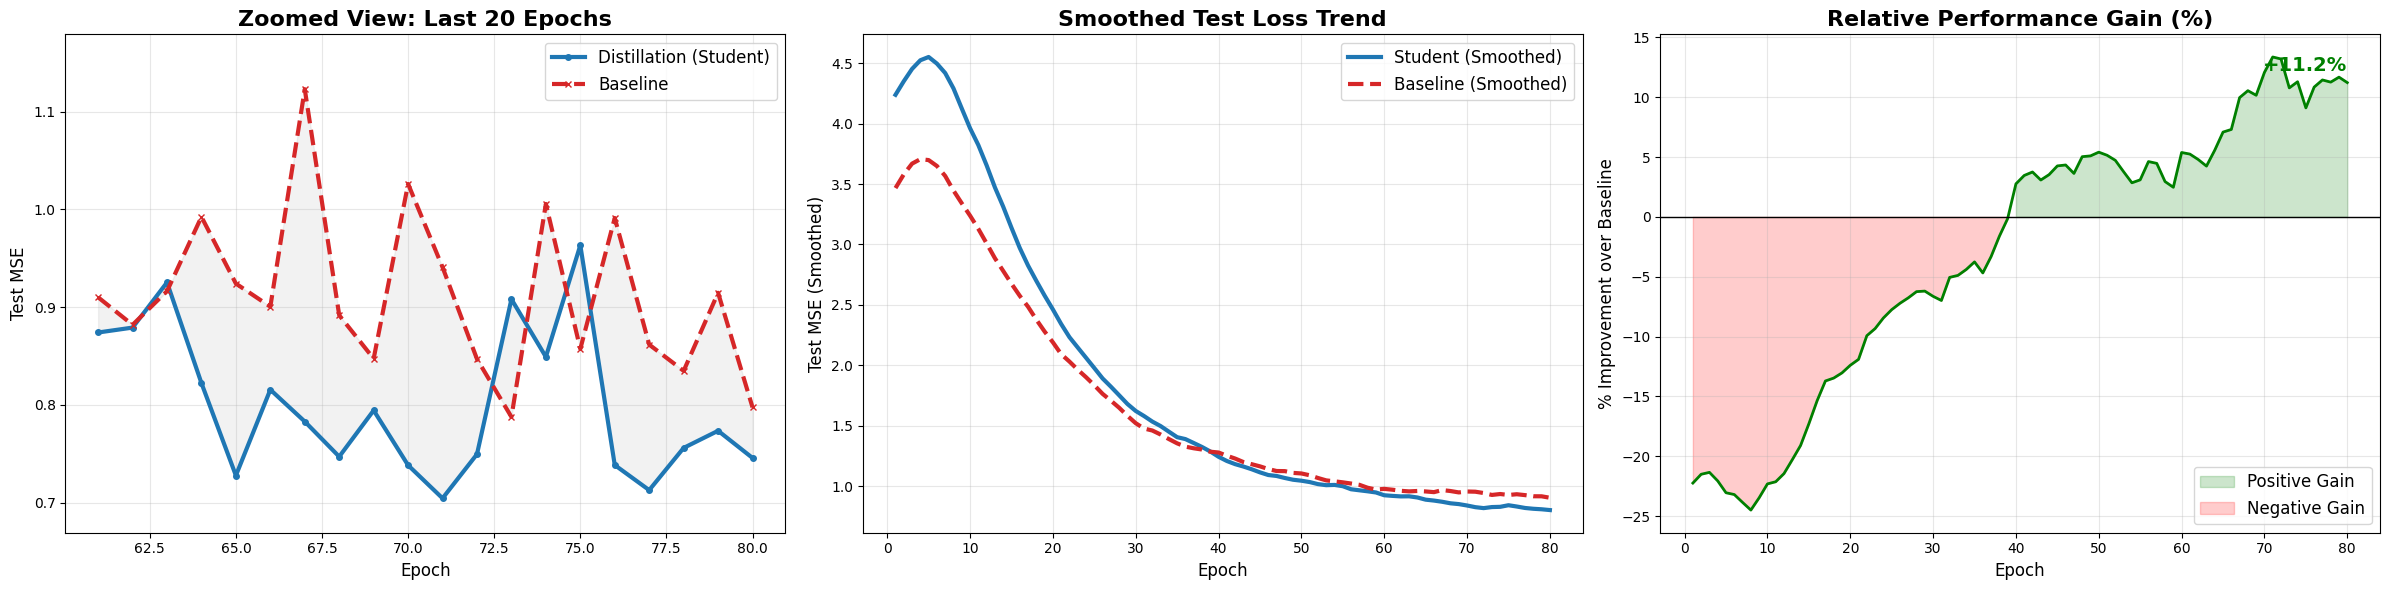

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 假设 history 变量还在内存中
# 如果没有，请重新运行上一段训练代码

def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

# 数据准备
epochs = range(1, len(history['distill_test']) + 1)
test_student = history['distill_test']
test_baseline = history['baseline_test']

# 创建一个 1行3列 的画布
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

# ==========================================
# 图 1: 聚焦视图 (The "Zoom-In")
# ==========================================
# 策略：只展示最后 20 个 epoch，并且限制 Y 轴范围
last_n = 20
if len(epochs) > last_n:
    zoom_epochs = epochs[-last_n:]
    zoom_student = test_student[-last_n:]
    zoom_baseline = test_baseline[-last_n:]
else:
    zoom_epochs = epochs
    zoom_student = test_student
    zoom_baseline = test_baseline

ax1.plot(zoom_epochs, zoom_student, label='Distillation (Student)', color='#1f77b4', linewidth=3, marker='o', markersize=4)
ax1.plot(zoom_epochs, zoom_baseline, label='Baseline', color='#d62728', linestyle='--', linewidth=3, marker='x', markersize=4)

# 动态设置 Y 轴范围，让差异看起来最大化
min_y = min(min(zoom_student), min(zoom_baseline)) * 0.95
max_y = max(max(zoom_student), max(zoom_baseline)) * 1.05
ax1.set_ylim(min_y, max_y)

ax1.set_title(f'Zoomed View: Last {last_n} Epochs', fontsize=16, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Test MSE', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12)
# 填充区域显示差距
ax1.fill_between(zoom_epochs, zoom_student, zoom_baseline, color='gray', alpha=0.1, label='Error Gap')

# ==========================================
# 图 2: 平滑趋势 (The "Clear Trend")
# ==========================================
# 策略：使用滑动平均或指数平滑消除抖动
smooth_student = smooth_curve(test_student, 0.9)
smooth_baseline = smooth_curve(test_baseline, 0.9)

ax2.plot(epochs, smooth_student, label='Student (Smoothed)', color='#1f77b4', linewidth=3)
ax2.plot(epochs, smooth_baseline, label='Baseline (Smoothed)', color='#d62728', linestyle='--', linewidth=3)

ax2.set_title('Smoothed Test Loss Trend', fontsize=16, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Test MSE (Smoothed)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12)

# ==========================================
# 图 3: 相对提升百分比 (The "Gain" Chart)
# ==========================================
# 策略：直接画出 (Baseline - Student) / Baseline
improvement = [(b - s) / b * 100 for s, b in zip(smooth_student, smooth_baseline)]

# 绘制正向收益区域
ax3.plot(epochs, improvement, color='green', linewidth=2)
ax3.fill_between(epochs, improvement, 0, where=[i > 0 for i in improvement], color='green', alpha=0.2, label='Positive Gain')
ax3.fill_between(epochs, improvement, 0, where=[i <= 0 for i in improvement], color='red', alpha=0.2, label='Negative Gain')
ax3.axhline(0, color='black', linewidth=1)

ax3.set_title('Relative Performance Gain (%)', fontsize=16, fontweight='bold')
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('% Improvement over Baseline', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='lower right', fontsize=12)

# 标注最终提升
final_gain = improvement[-1]
ax3.text(epochs[-1], final_gain + 1, f'+{final_gain:.1f}%', fontsize=14, color='green', fontweight='bold', ha='right')

plt.tight_layout()
plt.savefig('enhanced_comparison_plots.png', dpi=300)
plt.show()